Projeto TCC Ciência de dados 2026

In [126]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [127]:
df = pd.read_parquet(rf'data_voo\dados_completos.parquet')
df.head()

,dt_referencia,sg_empresa_icao,nr_etapa,nr_voo,sg_equipamento_icao,qt_assentos_previstos,sg_icao_origem,dt_partida_prevista_utc,sg_icao_destino,dt_chegada_prevista_utc,ds_tipo_servico,tx_codeshare
0,2018-03-29,TAP,1,0003,A332,269,LPPT,2018-03-29 17:10:00,SBSG,2018-03-30 00:40:00,REGULAR DE PASSAGEIROS INTERNACIONAL,AZU/7225 início: 26/03/2018 fim: 25/10/2018
1,2018-03-26,TAP,1,0003,A332,269,LPPT,2018-03-26 17:10:00,SBSG,2018-03-27 00:40:00,REGULAR DE PASSAGEIROS INTERNACIONAL,AZU/7225 início: 26/03/2018 fim: 25/10/2018
2,2018-03-31,TAP,1,0003,A332,269,LPPT,2018-03-31 17:10:00,SBSG,2018-04-01 00:40:00,REGULAR DE PASSAGEIROS INTERNACIONAL,AZU/7225 início: 26/03/2018 fim: 25/10/2018
3,2018-03-30,TAP,1,0004,A332,269,SBSG,2018-03-30 03:15:00,LPPT,2018-03-30 10:15:00,REGULAR DE PASSAGEIROS INTERNACIONAL,AZU/7519 início: 27/03/2018 fim: 26/10/2018
4,2018-03-27,TAP,1,0004,A332,269,SBSG,2018-03-27 03:15:00,LPPT,2018-03-27 10:15:00,REGULAR DE PASSAGEIROS INTERNACIONAL,AZU/7519 início: 27/03/2018 fim: 26/10/2018


In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6776573 entries, 0 to 6776572
Data columns (total 12 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   dt_referencia            datetime64[us]
 1   sg_empresa_icao          str           
 2   nr_etapa                 str           
 3   nr_voo                   str           
 4   sg_equipamento_icao      str           
 5   qt_assentos_previstos    str           
 6   sg_icao_origem           str           
 7   dt_partida_prevista_utc  datetime64[us]
 8   sg_icao_destino          str           
 9   dt_chegada_prevista_utc  datetime64[us]
 10  ds_tipo_servico          str           
 11  tx_codeshare             str           
dtypes: datetime64[us](3), str(9)
memory usage: 1.1 GB


In [129]:
df['ds_tipo_servico'].value_counts()

ds_tipo_servico
REGULAR DE PASSAGEIROS DOMÉSTICA                     5382597
REGULAR DE PASSAGEIROS INTERNACIONAL                  804378
SOBREVOOS OU TRASLADOS OPERACIONAIS INTERNACIONAL     229203
REGULAR DE CARGA INTERNACIONAL                        141622
REGULAR DE CARGA DOMÉSTICA                             68266
REGULAR DE CARGA DE CORREIO DOMÉSTICA                  57657
NÃO REGULAR DE PASSAGEIROS DOMÉSTICA                   36027
NÃO REGULAR DE CARGA INTERNACIONAL                     14724
NÃO REGULAR DE CARGA DOMÉSTICA                          9777
NÃO REGULAR DE PASSAGEIROS INTERNACIONAL                9736
REGULAR DOMÉSTICA                                       8982
REGULAR INTERNACIONAL                                   8099
SOBREVOOS OU TRASLADOS OPERACIONAIS DOMÉSTICA           3191
REGULAR DE CARGA OU CORREIO INTERNACIONAL               1385
NÃO REGULAR INTERNACIONAL                                435
NÃO REGULAR DOMÉSTICA                                    266
REGULAR 

In [130]:
df['nr_etapa'] = df['nr_etapa'].astype(int)
df['qt_assentos_previstos'] = df['qt_assentos_previstos'].astype(int)

In [131]:
maxDate = df['dt_referencia'].max()
minDate = df['dt_referencia'].min()
print(f'Min Date: {minDate}')
print(f'Max Date: {maxDate}')

Min Date: 2018-03-25 00:00:00
Max Date: 2025-12-31 00:00:00


In [132]:
df_voo = df[
    (df['dt_referencia'] < '2026-01-01') &
    (df['dt_referencia'] > '2019-01-01') &
    (df['ds_tipo_servico'] == 'REGULAR DE PASSAGEIROS DOMÉSTICA')
    ].copy()
df_voo.shape

(4765724, 12)

In [133]:
df_voo.info()

<class 'pandas.DataFrame'>
Index: 4765724 entries, 761045 to 6776528
Data columns (total 12 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   dt_referencia            datetime64[us]
 1   sg_empresa_icao          str           
 2   nr_etapa                 int64         
 3   nr_voo                   str           
 4   sg_equipamento_icao      str           
 5   qt_assentos_previstos    int64         
 6   sg_icao_origem           str           
 7   dt_partida_prevista_utc  datetime64[us]
 8   sg_icao_destino          str           
 9   dt_chegada_prevista_utc  datetime64[us]
 10  ds_tipo_servico          str           
 11  tx_codeshare             str           
dtypes: datetime64[us](3), int64(2), str(7)
memory usage: 790.0 MB


In [134]:
df_pub = pd.read_csv(rf'data_aerodromos\AerodromosPublicos.csv', sep=';', header=1)
df_pub.columns

Index(['CÓDIGO OACI', 'CIAD', 'NOME', 'MUNICÍPIO ATENDIDO', 'UF', 'LATITUDE',
       'LONGITUDE', 'ALTITUDE', 'OPERAÇÃO', 'OACI', 'AIP BRASIL', 'DESIGNAÇÃO',
       'COMPRIMENTO', 'LARGURA', 'RESISTÊNCIA', 'SUPERFÍCIE', 'DESIGNAÇÃO.1',
       'COMPRIMENTO.1', 'LARGURA.1', 'RESISTÊNCIA.1', 'SUPERFÍCIE.1',
       'DESIGNAÇÃO.2', 'COMPRIMENTO.2', 'LARGURA.2', 'RESISTÊNCIA.2',
       'SUPERFÍCIE.2', 'RAMPA(S) DE APROXIMAÇÃO', 'FORMATO DA ÁREA DE POUSO',
       'DIMENSÕES', 'RESISTÊNCIA.3', 'SUPERFÍCIE.3', 'p1', 'p2', 'p3', 'p4',
       'PORTARIAS', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38',
       'PORTARIA Nº 16.739/2025 e alterações',
       'Portaria nº 17.388/2025\nA Classe I se divide ainda em RBAC 121, RBAC 135 Regular e Outras Operações',
       'PORTARIA Nº 2007/2014 E ALTERAÇÕES\n(* = REGIME TARIFÁRIO DIFERENCIADO)',
       'AERONAVE CRÍTICA', 'TIPO DE APROX. (CABECEIRAS)', 'CAT SESCINC', 'r1',
       'r2', 'REFERÊNCIA(S)', 'RESTRIÇÃO(ÕES)', 'SITUAÇÃO', 'r1.1',
       'REFERÊNCI

In [135]:
df_pub_origem = df_pub.rename(columns={
    'CÓDIGO OACI': 'origem_icao',
    'MUNICÍPIO ATENDIDO': 'origem_cidade',
    'UF': 'origem_uf',
    'LATITUDE': 'origem_lat',
    'LONGITUDE': 'origem_lon',
    'ALTITUDE': 'origem_alt'
})
df_pub_destino = df_pub.rename(columns={
    'CÓDIGO OACI': 'destino_icao',
    'MUNICÍPIO ATENDIDO': 'destino_cidade',
    'UF': 'destino_uf',
    'LATITUDE': 'destino_lat',
    'LONGITUDE': 'destino_lon',
    'ALTITUDE': 'destino_alt'
})

In [136]:
df_voo.columns

Index(['dt_referencia', 'sg_empresa_icao', 'nr_etapa', 'nr_voo',
       'sg_equipamento_icao', 'qt_assentos_previstos', 'sg_icao_origem',
       'dt_partida_prevista_utc', 'sg_icao_destino', 'dt_chegada_prevista_utc',
       'ds_tipo_servico', 'tx_codeshare'],
      dtype='str')

In [137]:
df_voo = pd.merge(
    df_voo,
    df_pub_origem[['origem_icao', 'origem_cidade', 'origem_uf', 'origem_lat', 'origem_lon', 'origem_alt']],
    left_on='sg_icao_origem',
    right_on='origem_icao',
    how='left'
)

In [138]:
df_voo = pd.merge(
    df_voo,
    df_pub_destino[['destino_icao', 'destino_cidade', 'destino_uf', 'destino_lat', 'destino_lon', 'destino_alt']],
    left_on='sg_icao_destino',
    right_on='destino_icao',
    how='left'
)

In [139]:
df_voo = df_voo.dropna()
df_voo.info()

<class 'pandas.DataFrame'>
Index: 4751887 entries, 0 to 4765723
Data columns (total 24 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   dt_referencia            datetime64[us]
 1   sg_empresa_icao          str           
 2   nr_etapa                 int64         
 3   nr_voo                   str           
 4   sg_equipamento_icao      str           
 5   qt_assentos_previstos    int64         
 6   sg_icao_origem           str           
 7   dt_partida_prevista_utc  datetime64[us]
 8   sg_icao_destino          str           
 9   dt_chegada_prevista_utc  datetime64[us]
 10  ds_tipo_servico          str           
 11  tx_codeshare             str           
 12  origem_icao              str           
 13  origem_cidade            str           
 14  origem_uf                str           
 15  origem_lat               str           
 16  origem_lon               str           
 17  origem_alt               str           
 18

In [140]:
df_voo.head()

,dt_referencia,sg_empresa_icao,nr_etapa,nr_voo,sg_equipamento_icao,qt_assentos_previstos,sg_icao_origem,dt_partida_prevista_utc,sg_icao_destino,dt_chegada_prevista_utc,ds_tipo_servico,tx_codeshare,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt
0,2019-01-17,AMS,1,0017,C208,9,SWVC,2019-01-17 17:25:00,SWFX,2019-01-17 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m
1,2019-01-24,AMS,1,0017,C208,9,SWVC,2019-01-24 17:25:00,SWFX,2019-01-24 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m
2,2019-01-30,AMS,1,0017,C208,9,SWVC,2019-01-30 17:25:00,SWFX,2019-01-30 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m
3,2019-01-11,AMS,1,0017,C208,9,SWVC,2019-01-11 17:25:00,SWFX,2019-01-11 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m
4,2019-01-31,AMS,1,0017,C208,9,SWVC,2019-01-31 17:25:00,SWFX,2019-01-31 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m


In [141]:
df_voo['semana_do_ano'] = df_voo['dt_referencia'].dt.isocalendar().week
df_voo['mes'] = df_voo['dt_referencia'].dt.month
df_voo['ano'] = df_voo['dt_referencia'].dt.year

In [142]:
df_voo.sample(2)

,dt_referencia,sg_empresa_icao,nr_etapa,nr_voo,sg_equipamento_icao,qt_assentos_previstos,sg_icao_origem,dt_partida_prevista_utc,sg_icao_destino,dt_chegada_prevista_utc,ds_tipo_servico,tx_codeshare,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt,semana_do_ano,mes,ano
2549177,2023-02-04,AZU,1,4378,A20N,174,SBKP,2023-02-04 14:00:00,SBTE,2023-02-04 17:00:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SBKP,CAMPINAS,SP,23° 0' 25'' S,47° 8' 4'' W,661 m,SBTE,TERESINA,PI,5° 3' 38'' S,42° 49' 28'' W,67 m,5,2,2023
3497559,2024-05-04,TAM,1,3610,A320,180,SBGR,2024-05-04 10:20:00,SBPJ,2024-05-04 12:50:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SBGR,GUARULHOS,SP,23° 26' 8'' S,46° 28' 23'' W,750 m,SBPJ,PALMAS,TO,10° 17' 24'' S,48° 21' 28'' W,236 m,18,5,2024


In [143]:
df_voo.head(2)

,dt_referencia,sg_empresa_icao,nr_etapa,nr_voo,sg_equipamento_icao,qt_assentos_previstos,sg_icao_origem,dt_partida_prevista_utc,sg_icao_destino,dt_chegada_prevista_utc,ds_tipo_servico,tx_codeshare,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt,semana_do_ano,mes,ano
0,2019-01-17,AMS,1,0017,C208,9,SWVC,2019-01-17 17:25:00,SWFX,2019-01-17 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,3,1,2019
1,2019-01-24,AMS,1,0017,C208,9,SWVC,2019-01-24 17:25:00,SWFX,2019-01-24 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,4,1,2019


In [144]:
def dms_to_decimal(dms_str):
    if pd.isna(dms_str) or dms_str == '': return None
    parts = dms_str.replace('°', ' ').replace("'", ' ').replace("''", ' ').split()
    d, m, s, direction = float(parts[0]), float(parts[1]), float(parts[2]), parts[3]
    decimal = d + m/60 + s/3600
    if direction in ['S', 'W']:
        decimal *= -1
    return decimal

# Aplicando a conversão nas colunas de origem e destino
df_voo['origem_lat_dec'] =  df_voo['origem_lat'].apply(dms_to_decimal)
df_voo['origem_lon_dec'] =  df_voo['origem_lon'].apply(dms_to_decimal)
df_voo['destino_lat_dec'] = df_voo['destino_lat'].apply(dms_to_decimal)
df_voo['destino_lon_dec'] = df_voo['destino_lon'].apply(dms_to_decimal)

In [145]:
df_voo.head()

,dt_referencia,sg_empresa_icao,nr_etapa,nr_voo,sg_equipamento_icao,qt_assentos_previstos,sg_icao_origem,dt_partida_prevista_utc,sg_icao_destino,dt_chegada_prevista_utc,ds_tipo_servico,tx_codeshare,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt,semana_do_ano,mes,ano,origem_lat_dec,origem_lon_dec,destino_lat_dec,destino_lon_dec
0,2019-01-17,AMS,1,0017,C208,9,SWVC,2019-01-17 17:25:00,SWFX,2019-01-17 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,3,1,2019,-9.981111,-51.140556,-11.6325,-50.689444
1,2019-01-24,AMS,1,0017,C208,9,SWVC,2019-01-24 17:25:00,SWFX,2019-01-24 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,4,1,2019,-9.981111,-51.140556,-11.6325,-50.689444
2,2019-01-30,AMS,1,0017,C208,9,SWVC,2019-01-30 17:25:00,SWFX,2019-01-30 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,5,1,2019,-9.981111,-51.140556,-11.6325,-50.689444
3,2019-01-11,AMS,1,0017,C208,9,SWVC,2019-01-11 17:25:00,SWFX,2019-01-11 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,2,1,2019,-9.981111,-51.140556,-11.6325,-50.689444
4,2019-01-31,AMS,1,0017,C208,9,SWVC,2019-01-31 17:25:00,SWFX,2019-01-31 18:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,,SWVC,VILA RICA,MT,9° 58' 52'' S,51° 8' 26'' W,254 m,SWFX,SÃO FÉLIX DO ARAGUAIA,MT,11° 37' 57'' S,50° 41' 22'' W,199 m,5,1,2019,-9.981111,-51.140556,-11.6325,-50.689444


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

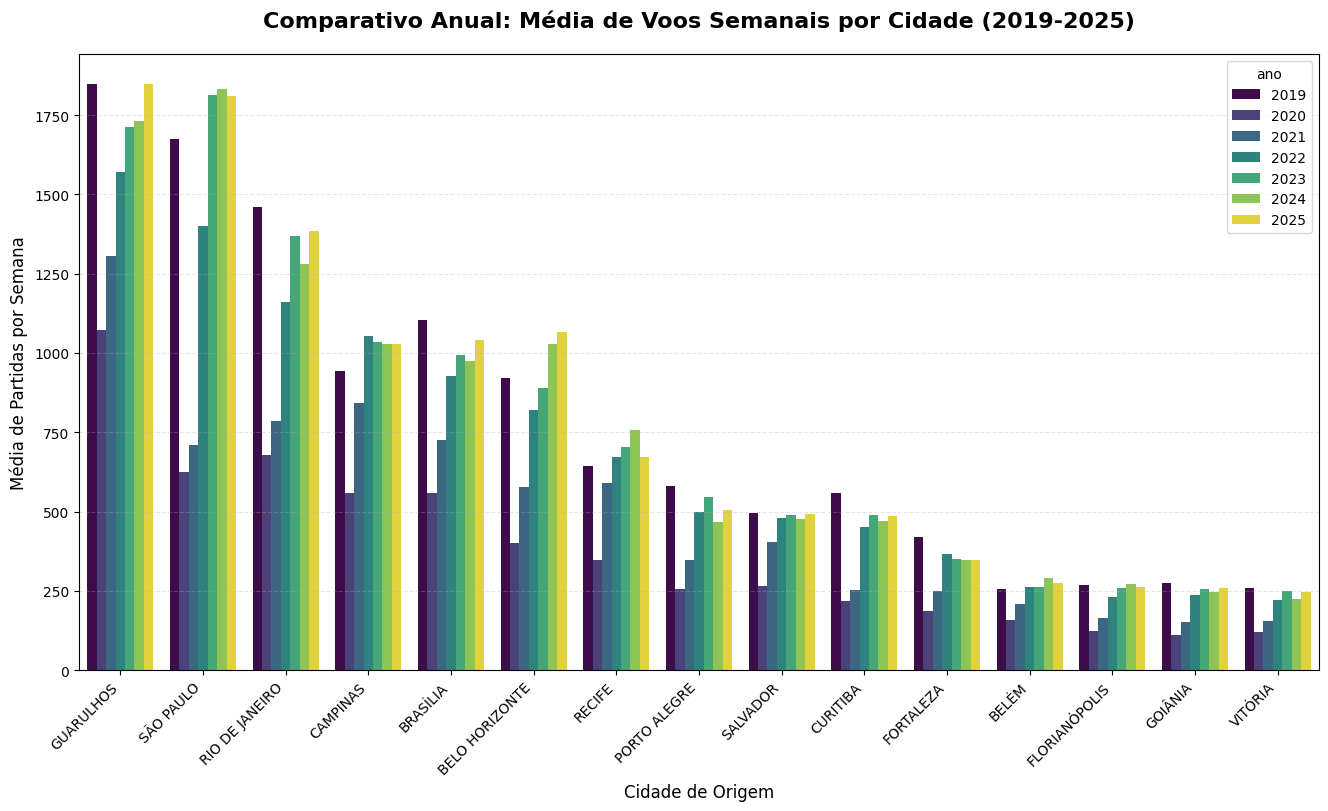

In [185]:
contagem_real = df_voo.groupby(['origem_cidade', 'ano', 'semana_do_ano']).size().reset_index(name='qtd_voos')
media_anual_cidade = contagem_real.groupby(['origem_cidade', 'ano'])['qtd_voos'].mean().reset_index()

top_15_geral = media_anual_cidade.groupby('origem_cidade')['qtd_voos'].mean().sort_values(ascending=False).head(15).index

df_plot = media_anual_cidade[media_anual_cidade['origem_cidade'].isin(top_15_geral)]

plt.figure(figsize=(16, 8))

sns.barplot(
    data=df_plot,
    x='origem_cidade',
    y='qtd_voos',
    hue='ano',
    palette='viridis',
    order=top_15_geral
)

plt.title('Comparativo Anual: Média de Voos Semanais por Cidade (2019-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cidade de Origem', fontsize=12)
plt.ylabel('Média de Partidas por Semana', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

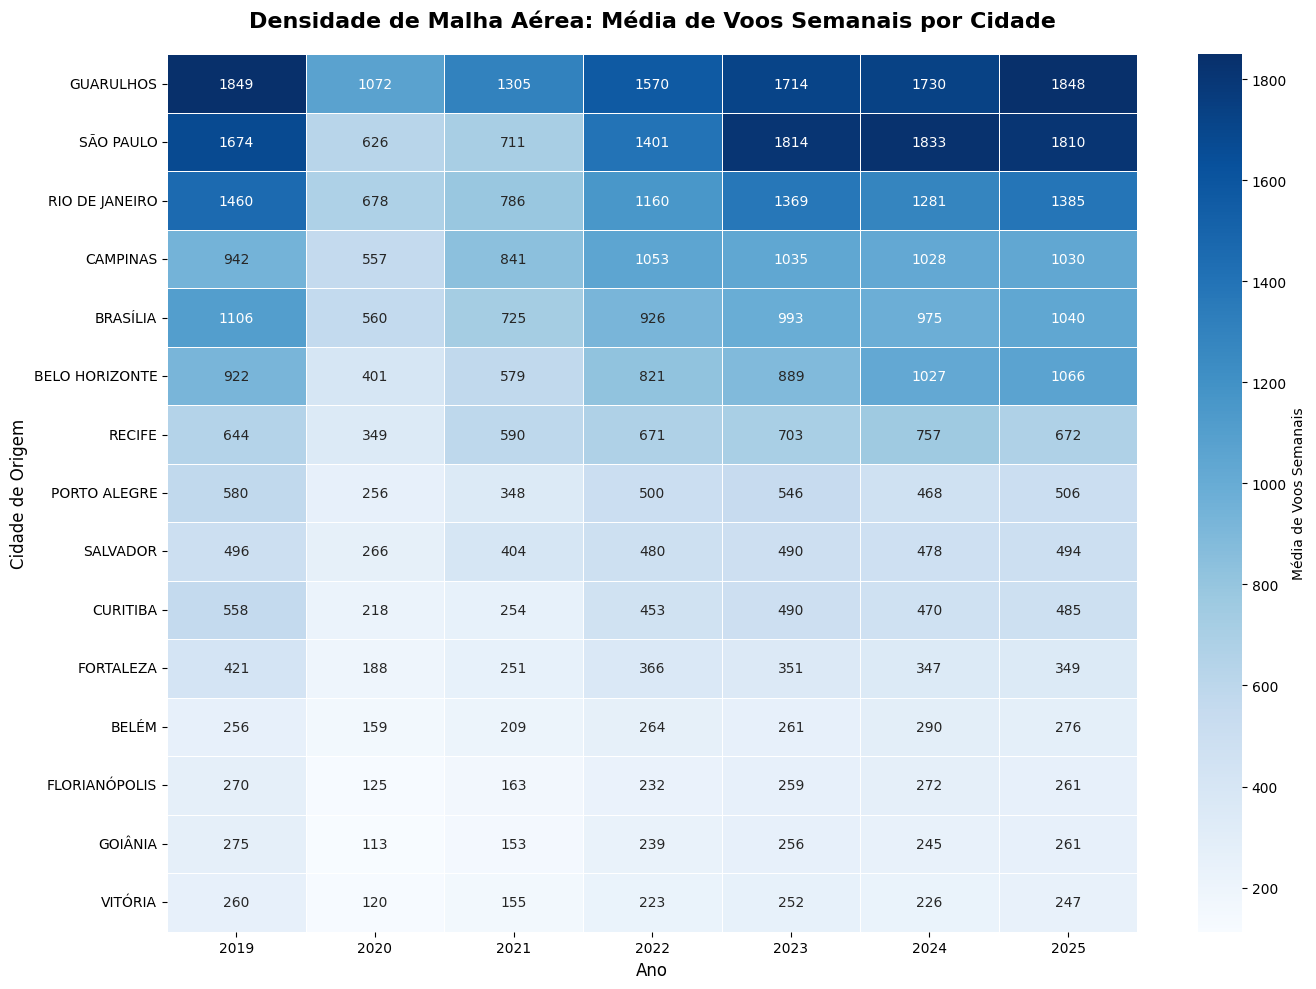

In [192]:
contagem_semanal = df_voo.groupby(['origem_cidade', 'ano', 'semana_do_ano']).size().reset_index(name='qtd_voos')
media_anual = contagem_semanal.groupby(['origem_cidade', 'ano'])['qtd_voos'].mean().reset_index()

# 2. Definir o ranking das Top 15 (pela média global)
top_15_geral = media_anual.groupby('origem_cidade')['qtd_voos'].mean().sort_values(ascending=False).head(15).index

# 3. Filtrar o DataFrame
df_plot = media_anual[media_anual['origem_cidade'].isin(top_15_geral)]

# 4. Criar a matriz para o Heatmap (Pivot Table)
# Index são as linhas (Cidades), Columns são as colunas (Anos) e Values é a cor (Média)
heatmap_data = df_plot.pivot(index="origem_cidade", columns="ano", values="qtd_voos")

# Reordenar as cidades para que a maior fique no topo
heatmap_data = heatmap_data.reindex(top_15_geral)

# 5. Plotagem
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data, 
    annot=True,          # Mostra os valores médios dentro dos quadrados
    fmt=".0f",           # Formata com 0 casas decimais
    cmap="Blues",        # Escala de azuis (claro para pouco, escuro para muito)
    linewidths=.5,       # Espaçamento entre os quadrados
    cbar_kws={'label': 'Média de Voos Semanais'},
    linecolor='white'
)

plt.title('Densidade de Malha Aérea: Média de Voos Semanais por Cidade', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Cidade de Origem', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx
import plotly.graph_objects as go

In [ ]:
# 1. Preparação dos Dados (Mantendo sua métrica de peso/frequência)
redes = df_voo.groupby(['origem_cidade', 'destino_cidade']).size().reset_index(name='peso')
top_redes = redes.sort_values('peso', ascending=False).head(300)

# 2. Criar o Grafo
G = nx.Graph()
for _, row in top_redes.iterrows():
    G.add_edge(row['origem_cidade'], row['destino_cidade'], weight=row['peso'])

# 3. Layout de Forças (Spring Layout)
# k=0.15 oferece um bom equilíbrio entre dispersão e agrupamento
pos = nx.spring_layout(G, k=0.15, iterations=100, seed=42)

# 4. Preparar Arestas (Linhas)
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='rgba(150,150,150,0.3)'),
    hoverinfo='none',
    mode='lines'
)

# 5. Preparar Nós (Cidades)
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]

# Métrica de grau: número de conexões únicas de cada cidade no Top 300
node_adjacencies = [len(list(G.neighbors(node))) for node in G.nodes()]

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=[f"{n}: {len(list(G.neighbors(n)))} conexões no Top 300" for n in G.nodes()],
    marker=dict(
        showscale=True,
        colorscale='Hot', 
        reversescale=False,
        color=node_adjacencies,
        size=[v * 2.5 for v in node_adjacencies], # Tamanho proporcional à conectividade
        opacity=0.85, 
        colorbar=dict(
            thickness=15,
            title=dict(text='Conexões', side='right'),
            xanchor='left',
            tickfont=dict(color='white')
        ),
        line_width=1,
        line_color='rgba(255, 255, 255, 0.5)'
    )
)

# 6. Configuração do Layout Final (Estilo Dark / Gephi)
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(
                    text='Topologia de Rede - Fluxo Principal de Voos (Cidades)',
                    font=dict(size=20, color='white'),
                    x=0.5
                ),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20, l=5, r=5, t=60),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                paper_bgcolor='black',
                plot_bgcolor='black',
                dragmode='pan' # Facilita a navegação 2D
                )
            )

fig.show()

In [178]:
redes = df_voo.groupby(['origem_cidade', 'destino_cidade']).size().reset_index(name='peso')
top_redes = redes.sort_values('peso', ascending=False).head(300)
top_redes.head(30)

,origem_cidade,destino_cidade,peso
1580,SÃO PAULO,RIO DE JANEIRO,118808
1373,RIO DE JANEIRO,SÃO PAULO,118699
250,BRASÍLIA,SÃO PAULO,48273
1537,SÃO PAULO,BRASÍLIA,48204
1350,RIO DE JANEIRO,GUARULHOS,46856
745,GUARULHOS,RIO DE JANEIRO,46680
148,BELO HORIZONTE,SÃO PAULO,46409
1533,SÃO PAULO,BELO HORIZONTE,46206
1336,RIO DE JANEIRO,BRASÍLIA,40328
242,BRASÍLIA,RIO DE JANEIRO,40315


In [ ]:
# 1. Preparação dos Dados - Soma de Assentos por Rota
# Agrupamos por trecho para definir a força da conexão
redes_pax = df_voo.groupby(['origem_cidade', 'destino_cidade'])['qt_assentos_previstos'].sum().reset_index(name='total_assentos')

# Filtramos as 300 rotas de maior capacidade para não poluir o gráfico
top_redes_pax = redes_pax.sort_values('total_assentos', ascending=False).head(300)

# 2. Criar o Grafo
G = nx.Graph()
for _, row in top_redes_pax.iterrows():
    G.add_edge(row['origem_cidade'], row['destino_cidade'], weight=row['total_assentos'])

# 3. Layout de Forças (Spring Layout)
# k=0.15 mantém o equilíbrio entre os grandes hubs e as cidades conectadas
pos = nx.spring_layout(G, k=0.15, iterations=100, seed=42)

# 4. Preparar Arestas (Linhas)
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='rgba(150,150,150,0.3)'),
    hoverinfo='none',
    mode='lines'
)

# 5. Preparar Nós (Cidades)
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]

# Calculamos o fluxo total de assentos por cidade (Soma dos pesos das arestas conectadas)
assentos_por_cidade = {node: sum(G.get_edge_data(node, n)['weight'] for n in G.neighbors(node)) for node in G.nodes()}
node_values = [assentos_por_cidade[node] for node in G.nodes()]

# Normalização para o tamanho dos círculos (Min-Max scaling para visualização)
max_val = max(node_values)
node_sizes = [(v / max_val) * 70 + 10 for v in node_values] 

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=[f"Cidade: {n}<br>Capacidade Total: {assentos_por_cidade[n]:,.0f} assentos" for n in G.nodes()],
    marker=dict(
        showscale=True,
        colorscale='Viridis', # Escala profissional: Roxo (baixo) -> Amarelo (alto)
        reversescale=False,
        color=node_values,
        size=node_sizes,
        colorbar=dict(
            thickness=15,
            title=dict(text='Total Assentos', side='right'),
            xanchor='left',
            tickfont=dict(color='white')
        ),
        line_width=1.5,
        line_color='rgba(255, 255, 255, 0.4)'
    )
)

# 6. Configuração do Layout Final (Estilo Dark / Moderno)
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(
                    text='Topologia de Rede: Capacidade de Oferta (Assentos Previstos)',
                    font=dict(size=22, color='white'),
                    x=0.5,
                    y=0.95
                ),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20, l=5, r=5, t=80),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                paper_bgcolor='black',
                plot_bgcolor='black',
                dragmode='pan'
                )
            )

fig.show()

In [200]:
top_redes_pax.head(30)

,origem_cidade,destino_cidade,total_assentos
1580,SÃO PAULO,RIO DE JANEIRO,17443607
1373,RIO DE JANEIRO,SÃO PAULO,17417355
250,BRASÍLIA,SÃO PAULO,8326894
1537,SÃO PAULO,BRASÍLIA,8298214
1350,RIO DE JANEIRO,GUARULHOS,7949072
745,GUARULHOS,RIO DE JANEIRO,7919219
148,BELO HORIZONTE,SÃO PAULO,7303213
1533,SÃO PAULO,BELO HORIZONTE,7278092
1180,PORTO ALEGRE,SÃO PAULO,6916516
1575,SÃO PAULO,PORTO ALEGRE,6899988


Apesar 